In [ ]:
!pip -q install stumpy numba pandas numpy matplotlib scikit-learn

In [ ]:
import os, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import stumpy

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

ZIP_PATH = "/content/ieee-fraud-detection.zip"
EXTRACT_DIR = "/content/ieee"

RANDOM_STATE = 42
SAMPLE_FRAC = 1.0

MISSING_THR = 0.80
CONST_THR = 0.99

SPLIT_TRAIN = 0.70
SPLIT_VALID = 0.85

K_LIST = [0.01, 0.005]
K_GRID = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

In [ ]:
!rm -rf "$EXTRACT_DIR"
!mkdir -p "$EXTRACT_DIR"
!unzip -q "$ZIP_PATH" -d "$EXTRACT_DIR"
!ls -la "$EXTRACT_DIR" | head

total 1323220
drwxr-xr-x 2 root root      4096 Mar 13 11:57 .
drwxr-xr-x 1 root root      4096 Mar 13 11:57 ..
-rw-r--r-- 1 root root   6080314 Dec 11  2019 sample_submission.csv
-rw-r--r-- 1 root root  25797161 Dec 11  2019 test_identity.csv
-rw-r--r-- 1 root root 613194934 Dec 11  2019 test_transaction.csv
-rw-r--r-- 1 root root  26529680 Dec 11  2019 train_identity.csv
-rw-r--r-- 1 root root 683351067 Dec 11  2019 train_transaction.csv


In [ ]:
train_path = f"{EXTRACT_DIR}/train_transaction.csv"

usecols = ["TransactionDT", "TransactionAmt", "isFraud"]
dtypes = {"TransactionDT": "int64", "TransactionAmt": "float32", "isFraud": "int8"}

df = pd.read_csv(train_path, usecols=usecols, dtype=dtypes)
df = df.sort_values("TransactionDT").reset_index(drop=True)

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).sort_values("TransactionDT").reset_index(drop=True)

print("shape:", df.shape)
print("fraud_rate:", float(df["isFraud"].mean()))
print("missing_ratio:", df.isna().mean().to_dict())

df["TransactionAmt"] = df["TransactionAmt"].fillna(0.0)
df.head()

shape: (590540, 3)
fraud_rate: 0.03499000914417313
missing_ratio: {'isFraud': 0.0, 'TransactionDT': 0.0, 'TransactionAmt': 0.0}


,isFraud,TransactionDT,TransactionAmt
0,0,86400,68.5
1,0,86401,29.0
2,0,86469,59.0
3,0,86499,50.0
4,0,86506,50.0


In [ ]:
def drop_high_missing_cols(df, cols, thr):
    miss = df[cols].isna().mean()
    return miss[miss > thr].index.tolist()

def drop_quasi_constant_cols(df, cols, thr):
    drops = []
    n = len(df)
    for c in cols:
        vc = df[c].value_counts(dropna=False)
        if len(vc) == 0:
            drops.append(c)
            continue
        top_ratio = float(vc.iloc[0]) / float(n)
        if top_ratio > thr:
            drops.append(c)
    return drops

cols = ["TransactionDT", "TransactionAmt", "isFraud"]
drop_miss = drop_high_missing_cols(df, cols, MISSING_THR)
cols2 = [c for c in cols if c not in set(drop_miss)]
drop_const = drop_quasi_constant_cols(df, cols2, CONST_THR)

print("drop_missing:", drop_miss)
print("drop_const:", drop_const)

drop_missing: []
drop_const: []


In [ ]:
def build_time_series(df, bin_seconds):
    dt = df["TransactionDT"].values.astype(np.int64)
    amt = df["TransactionAmt"].values.astype(np.float64)
    y = df["isFraud"].values.astype(np.int8)

    t0 = dt.min()
    bins = ((dt - t0) // bin_seconds).astype(np.int32)
    n_bins = int(bins.max()) + 1

    count = np.bincount(bins, minlength=n_bins).astype(np.float64)
    amt_sum = np.bincount(bins, weights=amt, minlength=n_bins).astype(np.float64)
    amt_mean = amt_sum / np.maximum(1.0, count)
    fraud_cnt = np.bincount(bins, weights=y.astype(np.float64), minlength=n_bins).astype(np.float64)

    ts = {
        "count": count,
        "amt_sum": amt_sum,
        "amt_mean": amt_mean,
        "log_count": np.log1p(count),
        "log_amt_sum": np.log1p(amt_sum),
        "fraud_cnt": fraud_cnt,
    }
    return bins, ts, n_bins, t0

In [ ]:
def damp_scores_from_series(T, M, i_train_end, normalize=True):
    T_ref = T[:i_train_end]
    mp = stumpy.stump(T, M, T_B=T_ref, ignore_trivial=False, normalize=normalize)
    mp_dist = mp[:, 0].astype(np.float64)

    mp_dist[:max(0, i_train_end - M + 1)] = 0.0

    n = len(T)
    bin_score = np.zeros(n, dtype=np.float64)

    for start_idx, s in enumerate(mp_dist):
        end_idx = start_idx + M - 1
        if end_idx < n and s > bin_score[end_idx]:
            bin_score[end_idx] = s

    return bin_score

In [ ]:
def topk_indices(scores, k_frac):
    k = max(1, int(len(scores) * k_frac))
    return np.argsort(scores)[-k:]

def aml_metrics(y_true, scores, amt=None, k_list=(0.01, 0.005)):
    ap = float(average_precision_score(y_true, scores)) if len(np.unique(y_true)) > 1 else 0.0
    out = {"PR_AUC(AP)": ap}
    for k in k_list:
        idx = topk_indices(scores, k)
        out[f"Precision@{int(k*1000)/10}%"] = float(y_true[idx].mean()) if len(idx) else 0.0
        out[f"Recall@{int(k*1000)/10}%"] = float(y_true[idx].sum() / max(1, y_true.sum()))
        if amt is not None:
            fraud_amt_total = amt[y_true == 1].sum()
            fraud_amt_caught = amt[idx][y_true[idx] == 1].sum() if len(idx) else 0.0
            out[f"AmtRecall@{int(k*1000)/10}%"] = float(fraud_amt_caught / fraud_amt_total) if fraud_amt_total > 0 else 0.0
    return out

def pick_threshold_max_f1(y_true, scores, n_thr=200):
    qs = np.linspace(0.80, 0.9995, n_thr)
    thr_grid = np.unique(np.quantile(scores, qs))
    best_thr, best_f1 = 0.0, -1.0
    for thr in thr_grid:
        y_pred = (scores >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)
    return best_thr, float(best_f1)

def eval_basic_metrics(y_true, scores, thr):
    roc = float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) > 1 else 0.0
    ap = float(average_precision_score(y_true, scores)) if len(np.unique(y_true)) > 1 else 0.0
    y_pred = (scores >= thr).astype(int)
    f1 = float(f1_score(y_true, y_pred, zero_division=0))
    return {"ROC_AUC": roc, "PR_AUC(AP)": ap, "F1": f1, "thr": float(thr)}, y_pred

In [ ]:
BIN_SECONDS = 3600
SERIES_MODE = "count"
M = 24
NORMALIZE = True

bins, ts_dict, n_bins, t0 = build_time_series(df, BIN_SECONDS)
T = ts_dict[SERIES_MODE]

i_train_end = int(n_bins * SPLIT_TRAIN)
i_valid_end = int(n_bins * SPLIT_VALID)

bin_score = damp_scores_from_series(T, M, i_train_end, normalize=NORMALIZE)

score_tx = bin_score[bins]
y = df["isFraud"].values.astype(int)
amt = df["TransactionAmt"].values.astype(np.float64)

valid_mask = (bins >= i_train_end) & (bins < i_valid_end)
test_mask  = (bins >= i_valid_end)

scores_valid = score_tx[valid_mask]
y_valid = y[valid_mask]
amt_valid = amt[valid_mask]

scores_test = score_tx[test_mask]
y_test = y[test_mask]
amt_test = amt[test_mask]

thr_base, f1_base_valid = pick_threshold_max_f1(y_valid, scores_valid, n_thr=250)

m_valid_base, yhat_valid_base = eval_basic_metrics(y_valid, scores_valid, thr_base)
m_test_base,  yhat_test_base  = eval_basic_metrics(y_test,  scores_test,  thr_base)

print("BASE params:", {"BIN_SECONDS":BIN_SECONDS,"SERIES_MODE":SERIES_MODE,"M":M,"NORMALIZE":NORMALIZE})
print("BASE valid:", m_valid_base, aml_metrics(y_valid, scores_valid, amt_valid, K_LIST))
print("BASE test :", m_test_base,  aml_metrics(y_test,  scores_test,  amt_test,  K_LIST))

BASE params: {'BIN_SECONDS': 3600, 'SERIES_MODE': 'count', 'M': 24, 'NORMALIZE': True}
BASE valid: {'ROC_AUC': 0.48851053091582913, 'PR_AUC(AP)': 0.03278350341221925, 'F1': 0.0521692120556832, 'thr': 1.0733565106145015} {'PR_AUC(AP)': 0.03278350341221925, 'Precision@1.0%': 0.017264276228419653, 'Recall@1.0%': 0.00497893527384144, 'AmtRecall@1.0%': 0.006841407091899655, 'Precision@0.5%': 0.02127659574468085, 'Recall@0.5%': 0.003063960168517809, 'AmtRecall@0.5%': 0.003831032418591286}
BASE test : {'ROC_AUC': 0.4817586753428836, 'PR_AUC(AP)': 0.03204724402186834, 'F1': 0.045817304931963024, 'thr': 1.0733565106145015} {'PR_AUC(AP)': 0.03204724402186834, 'Precision@1.0%': 0.02207792207792208, 'Recall@1.0%': 0.006322052807735217, 'AmtRecall@1.0%': 0.007893477397279497, 'Precision@0.5%': 0.023376623376623377, 'Recall@0.5%': 0.00334696913350688, 'AmtRecall@0.5%': 0.006257991484096812}


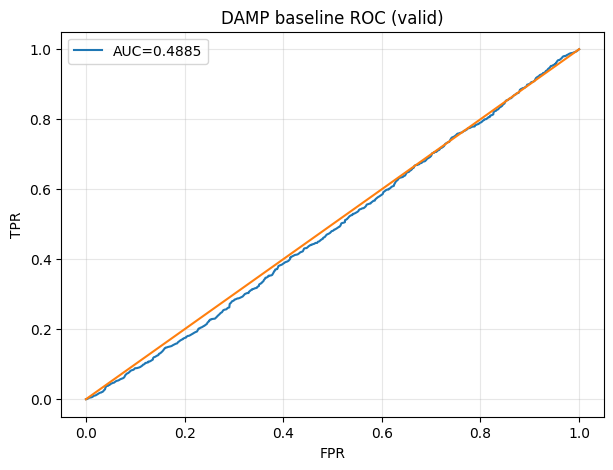

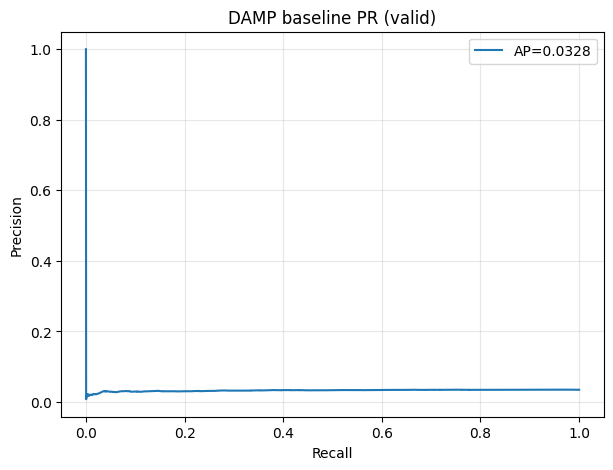

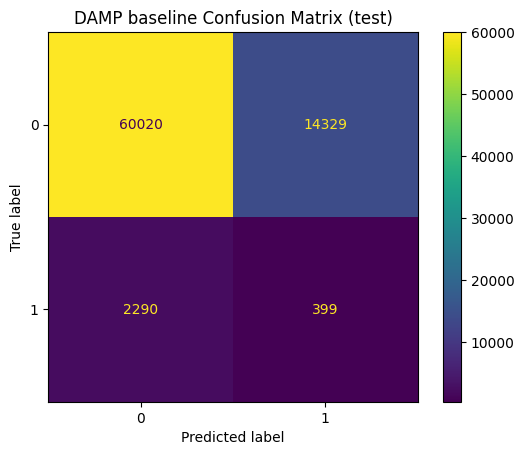

In [ ]:
fpr, tpr, _ = roc_curve(y_valid, scores_valid)
aucv = roc_auc_score(y_valid, scores_valid) if len(np.unique(y_valid)) > 1 else 0.0

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC={aucv:.4f}")
plt.plot([0,1],[0,1])
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("DAMP baseline ROC (valid)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

p, r, _ = precision_recall_curve(y_valid, scores_valid)
apv = average_precision_score(y_valid, scores_valid) if len(np.unique(y_valid)) > 1 else 0.0

plt.figure(figsize=(7,5))
plt.plot(r, p, label=f"AP={apv:.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("DAMP baseline PR (valid)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

cm = confusion_matrix(y_test, yhat_test_base)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title("DAMP baseline Confusion Matrix (test)")
plt.show()

In [ ]:
BIN_LIST = [1800, 3600, 7200]
M_LIST = [12, 24, 48]
SERIES_LIST = ["count", "log_count", "amt_sum", "log_amt_sum", "amt_mean"]
NORM_LIST = [True, False]

rows = []
for bs in BIN_LIST:
    bins_, ts_, n_bins_, _ = build_time_series(df, bs)
    i_train_end_ = int(n_bins_ * SPLIT_TRAIN)
    i_valid_end_ = int(n_bins_ * SPLIT_VALID)

    y_all = df["isFraud"].values.astype(int)
    amt_all = df["TransactionAmt"].values.astype(np.float64)

    valid_mask_ = (bins_ >= i_train_end_) & (bins_ < i_valid_end_)

    for sm in SERIES_LIST:
        T_ = ts_[sm]
        for m in M_LIST:
            if i_train_end_ <= m + 2:
                continue
            for norm in NORM_LIST:
                bin_score_ = damp_scores_from_series(T_, m, i_train_end_, normalize=norm)
                score_tx_ = bin_score_[bins_]

                sv = score_tx_[valid_mask_]
                yv = y_all[valid_mask_]

                thr, f1v = pick_threshold_max_f1(yv, sv, n_thr=150)
                met, _ = eval_basic_metrics(yv, sv, thr)

                rows.append({
                    "BIN_SECONDS": bs,
                    "SERIES_MODE": sm,
                    "M": m,
                    "NORMALIZE": norm,
                    "valid_ROC_AUC": met["ROC_AUC"],
                    "valid_PR_AUC": met["PR_AUC(AP)"],
                    "valid_F1": met["F1"],
                    "thr": met["thr"],
                })

tune_df = pd.DataFrame(rows).sort_values(["valid_PR_AUC", "valid_F1"], ascending=False)
display(tune_df.head(25))
best = tune_df.iloc[0].to_dict()
best

,BIN_SECONDS,SERIES_MODE,M,NORMALIZE,valid_ROC_AUC,valid_PR_AUC,valid_F1,thr
77,7200,amt_sum,48,False,0.506012,0.037423,0.071035,65897.593280
85,7200,amt_mean,12,False,0.516026,0.036857,0.065763,70.635369
89,7200,amt_mean,48,False,0.510091,0.036775,0.066862,244.089520
58,3600,amt_mean,48,True,0.513499,0.036450,0.069326,6.265776
56,3600,amt_mean,24,True,0.512654,0.036154,0.060539,3.860901
86,7200,amt_mean,24,True,0.496064,0.035965,0.062828,3.600405
84,7200,amt_mean,12,True,0.510924,0.035882,0.062001,1.892946
28,1800,amt_mean,48,True,0.513366,0.035844,0.067229,6.219727
22,1800,log_amt_sum,48,True,0.506629,0.035668,0.062312,2.476445
76,7200,amt_sum,48,True,0.501878,0.035619,0.065653,2.418452


{'BIN_SECONDS': 7200,
 'SERIES_MODE': 'amt_sum',
 'M': 48,
 'NORMALIZE': False,
 'valid_ROC_AUC': 0.5060119775568999,
 'valid_PR_AUC': 0.03742285042502065,
 'valid_F1': 0.07103457554150411,
 'thr': 65897.59327992982}

BEST params: {'BIN_SECONDS': 7200, 'SERIES_MODE': 'amt_sum', 'M': 48, 'NORMALIZE': False}
BEST valid: {'ROC_AUC': 0.5060119775568999, 'PR_AUC(AP)': 0.03742285042502065, 'F1': 0.07103457554150411, 'thr': 65897.59327992982} {'PR_AUC(AP)': 0.03742285042502065, 'Precision@1.0%': 0.06772908366533864, 'Recall@1.0%': 0.019525267993874426, 'AmtRecall@1.0%': 0.018804493108716357, 'Precision@0.5%': 0.07180851063829788, 'Recall@0.5%': 0.010336906584992343, 'AmtRecall@0.5%': 0.007737556893692812}
BEST test : {'ROC_AUC': 0.49317273387572114, 'PR_AUC(AP)': 0.03450027414028141, 'F1': 0.04380182862002977, 'thr': 65897.59327992982} {'PR_AUC(AP)': 0.03450027414028141, 'Precision@1.0%': 0.046753246753246755, 'Recall@1.0%': 0.01338787653402752, 'AmtRecall@1.0%': 0.014028588210480572, 'Precision@0.5%': 0.06233766233766234, 'Recall@0.5%': 0.008925251022685012, 'AmtRecall@0.5%': 0.012397521046049928}


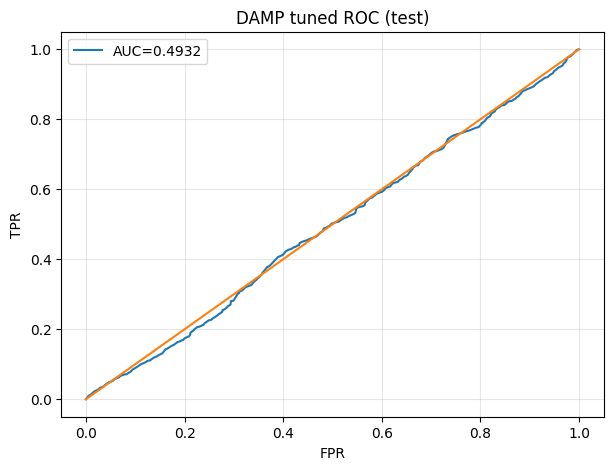

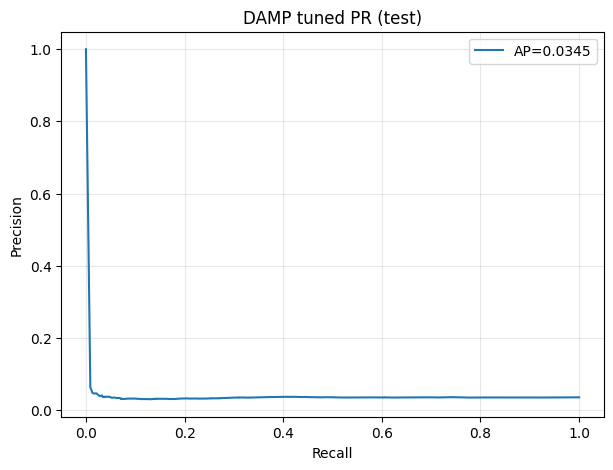

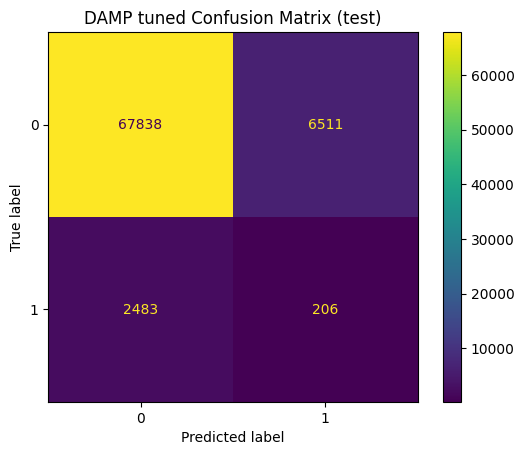

In [ ]:
BIN_SECONDS = int(best["BIN_SECONDS"])
SERIES_MODE = best["SERIES_MODE"]
M = int(best["M"])
NORMALIZE = bool(best["NORMALIZE"])

bins, ts_dict, n_bins, t0 = build_time_series(df, BIN_SECONDS)
T = ts_dict[SERIES_MODE]

i_train_end = int(n_bins * SPLIT_TRAIN)
i_valid_end = int(n_bins * SPLIT_VALID)

bin_score = damp_scores_from_series(T, M, i_train_end, normalize=NORMALIZE)
score_tx = bin_score[bins]

y = df["isFraud"].values.astype(int)
amt = df["TransactionAmt"].values.astype(np.float64)

valid_mask = (bins >= i_train_end) & (bins < i_valid_end)
test_mask  = (bins >= i_valid_end)

scores_valid = score_tx[valid_mask]
y_valid = y[valid_mask]
amt_valid = amt[valid_mask]

scores_test = score_tx[test_mask]
y_test = y[test_mask]
amt_test = amt[test_mask]

thr_best, _ = pick_threshold_max_f1(y_valid, scores_valid, n_thr=250)

m_valid_best, yhat_valid_best = eval_basic_metrics(y_valid, scores_valid, thr_best)
m_test_best,  yhat_test_best  = eval_basic_metrics(y_test,  scores_test,  thr_best)

print("BEST params:", {"BIN_SECONDS":BIN_SECONDS,"SERIES_MODE":SERIES_MODE,"M":M,"NORMALIZE":NORMALIZE})
print("BEST valid:", m_valid_best, aml_metrics(y_valid, scores_valid, amt_valid, K_LIST))
print("BEST test :", m_test_best,  aml_metrics(y_test,  scores_test,  amt_test,  K_LIST))

fpr, tpr, _ = roc_curve(y_test, scores_test)
auct = roc_auc_score(y_test, scores_test) if len(np.unique(y_test)) > 1 else 0.0

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC={auct:.4f}")
plt.plot([0,1],[0,1])
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("DAMP tuned ROC (test)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

p, r, _ = precision_recall_curve(y_test, scores_test)
apt = average_precision_score(y_test, scores_test) if len(np.unique(y_test)) > 1 else 0.0

plt.figure(figsize=(7,5))
plt.plot(r, p, label=f"AP={apt:.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("DAMP tuned PR (test)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

cm = confusion_matrix(y_test, yhat_test_best)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title("DAMP tuned Confusion Matrix (test)")
plt.show()

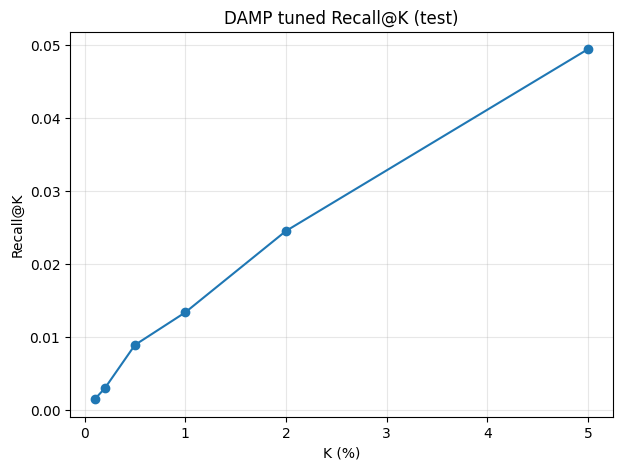

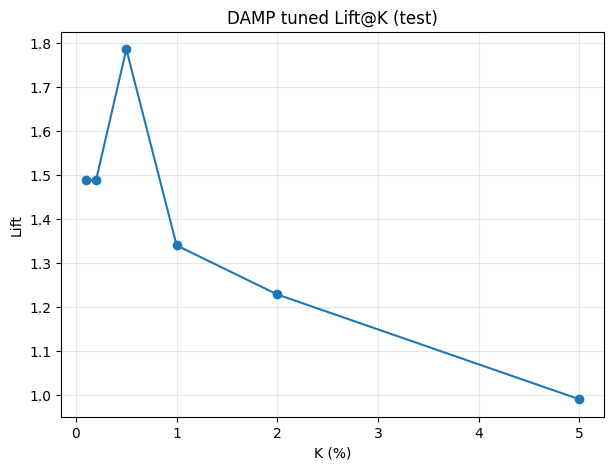

In [ ]:
base = float(y_test.mean())
prec_list, rec_list = [], []

for k in K_GRID:
    idx = topk_indices(scores_test, k)
    prec = float(y_test[idx].mean()) if len(idx) else 0.0
    rec  = float(y_test[idx].sum() / max(1, y_test.sum()))
    prec_list.append(prec)
    rec_list.append(rec)

plt.figure(figsize=(7,5))
plt.plot([k*100 for k in K_GRID], rec_list, marker="o")
plt.xlabel("K (%)")
plt.ylabel("Recall@K")
plt.title("DAMP tuned Recall@K (test)")
plt.grid(True, alpha=0.3)
plt.show()

lift = [(p/base if base > 0 else np.nan) for p in prec_list]
plt.figure(figsize=(7,5))
plt.plot([k*100 for k in K_GRID], lift, marker="o")
plt.xlabel("K (%)")
plt.ylabel("Lift")
plt.title("DAMP tuned Lift@K (test)")
plt.grid(True, alpha=0.3)
plt.show()